Question 7<br>
Zoom using nearest-neighbor, bilinear interpolation

In [ ]:
import cv2 as cv
import numpy as np

def zoom_nearest_neighbour(img, scale):
    h, w = img.shape
    new_h, new_w = int(h * scale), int(w * scale)

    zoomed = np.zeros((new_h, new_w), dtype=img.dtype)

    for i in range(new_h):
        for j in range(new_w):
            # Map back to original image
            x = int(round(i / scale))
            y = int(round(j / scale))
            x = min(x, h - 1)
            y = min(y, w - 1)
            
            zoomed[i, j] = img[x, y]

    return zoomed

def zoom_bilinear(img, scale):
    h, w = img.shape
    new_h, new_w = int(h * scale), int(w * scale)

    zoomed = np.zeros((new_h, new_w), dtype=np.float64)

    for i in range(new_h):
        for j in range(new_w):
            # Map back to original
            x = i / scale
            y = j / scale

            x1 = int(np.floor(x))
            y1 = int(np.floor(y))
            x2 = min(x1 + 1, h - 1)
            y2 = min(y1 + 1, w - 1)

            dx = x - x1
            dy = y - y1

            # Interpolation
            value = (
                (1 - dx) * (1 - dy) * img[x1, y1] +
                dx * (1 - dy) * img[x2, y1] +
                (1 - dx) * dy * img[x1, y2] +
                dx * dy * img[x2, y2]
            )

            zoomed[i, j] = value

    return zoomed.astype(img.dtype)

def normalized_ssd(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    ssd = np.sum((img1 - img2) ** 2)
    norm_ssd = ssd / img1.size

    return norm_ssd

# Open images in grayscale and show the zoomed one with the original
img1 = cv.imread('im01.png', cv.IMREAD_GRAYSCALE)
img1small = cv.imread('im01small.png', cv.IMREAD_GRAYSCALE)

img2 = cv.imread('im02.png', cv.IMREAD_GRAYSCALE)
img2small = cv.imread('im02small.png', cv.IMREAD_GRAYSCALE)

img3 = cv.imread('im03.png', cv.IMREAD_GRAYSCALE)
img3small = cv.imread('im03small.png', cv.IMREAD_GRAYSCALE)

scale = img1.shape[0] / img1small.shape[0]
img1_z_nn = zoom_nearest_neighbour(img1small, scale)
img1_z_bl = zoom_bilinear(img1small, scale)

img1_nn_ssd = normalized_ssd(img1_z_nn, img1)
img1_bl_ssd = normalized_ssd(img1_z_bl, img1)
print("Image 01")
print(f"Normalized SSD between Original and Zoomed (sacel:{scale}) using Nearest Neighbour: {img1_nn_ssd}")
print(f"Normalized SSD between Original and Zoomed (sacel:{scale}) using Bilinear: {img1_bl_ssd}")
print("")

Image 01
Normalized SSD between Original and Zoomed (sacel:4.0) using Nearest Neighbour: 256.8221937692901
Normalized SSD between Original and Zoomed (sacel:4.0) using Bilinear: 201.4493962191358



In [15]:
# Image 02
scale = img2.shape[0] / img2small.shape[0]
img2_z_nn = zoom_nearest_neighbour(img2small, scale)
img2_z_bl = zoom_bilinear(img2small, scale)

img2_nn_ssd = normalized_ssd(img2_z_nn, img2)
img2_bl_ssd = normalized_ssd(img2_z_bl, img2)
print("Image 02")
print(f"Normalized SSD between Original and Zoomed (sacel:{scale}) using Nearest Neighbour: {img2_nn_ssd}")
print(f"Normalized SSD between Original and Zoomed (sacel:{scale}) using Bilinear: {img2_bl_ssd}")
print("")

Image 02
Normalized SSD between Original and Zoomed (sacel:4.0) using Nearest Neighbour: 65.41742491319444
Normalized SSD between Original and Zoomed (sacel:4.0) using Bilinear: 49.55644184027778



Text(0.5, 1.0, 'Zoomed Image 02 (Bilinear)')

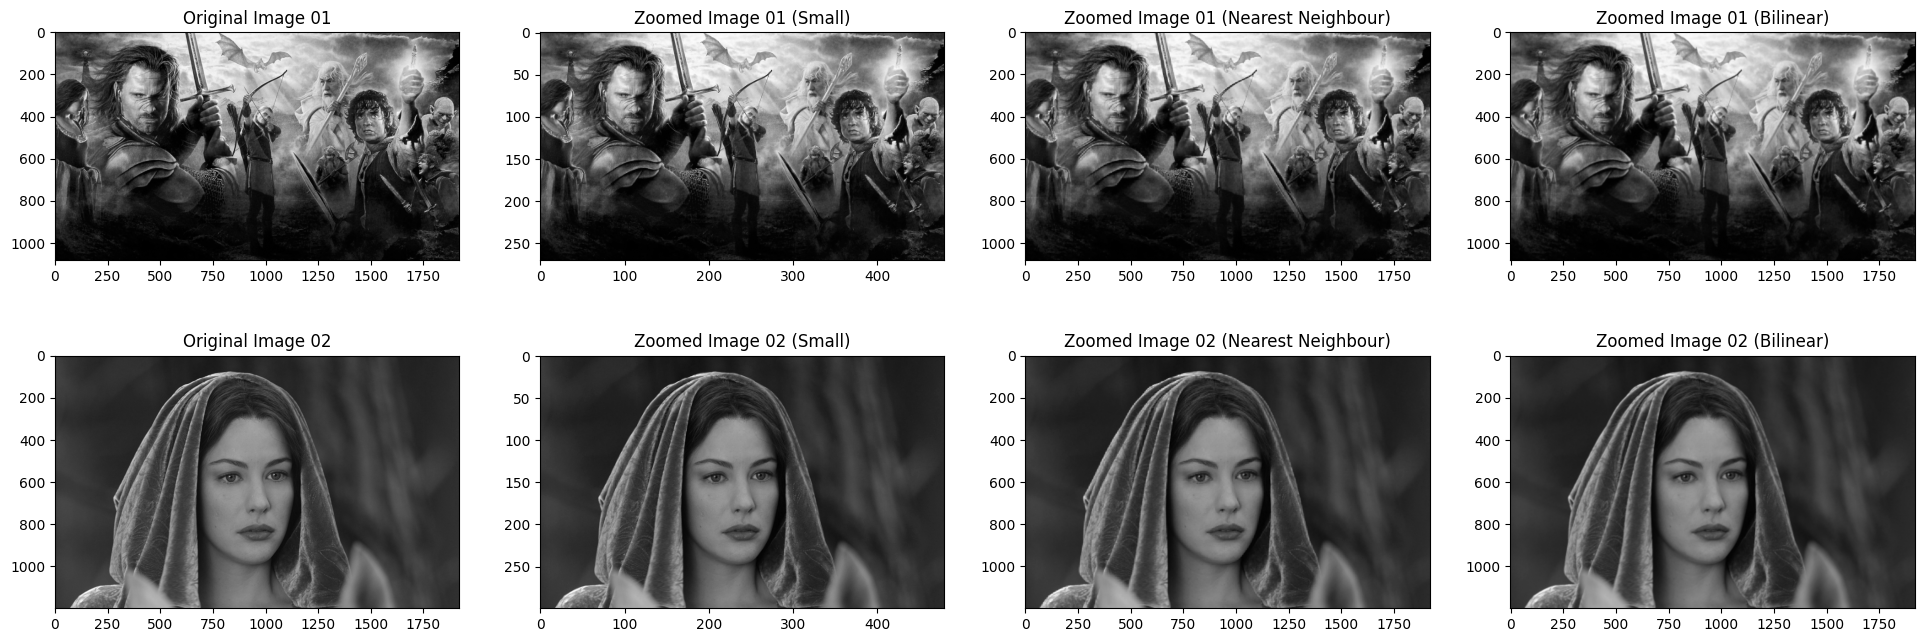

In [21]:
# Show imges
import matplotlib.pyplot as plt

# Some plots to show the images
plot, axis = plt.subplots(2, 4, figsize=(24, 8))
axis[0,0].imshow(img1, cmap='gray')
axis[0,0].set_title("Original Image 01")
axis[0,1].imshow(img1small, cmap='gray')
axis[0,1].set_title("Zoomed Image 01 (Small)")
axis[0,2].imshow(img1_z_nn, cmap='gray')
axis[0,2].set_title("Zoomed Image 01 (Nearest Neighbour)")
axis[0,3].imshow(img1_z_bl, cmap='gray')
axis[0,3].set_title("Zoomed Image 01 (Bilinear)")

axis[1,0].imshow(img2, cmap='gray')
axis[1,0].set_title("Original Image 02")
axis[1,1].imshow(img2small, cmap='gray')
axis[1,1].set_title("Zoomed Image 02 (Small)")
axis[1,2].imshow(img2_z_nn, cmap='gray')
axis[1,2].set_title("Zoomed Image 02 (Nearest Neighbour)")
axis[1,3].imshow(img2_z_bl, cmap='gray')
axis[1,3].set_title("Zoomed Image 02 (Bilinear)")


